In [ ]:
#!/usr/bin/env python3
"""
main.py
=======
Entry point and configuration hub for the UNO-card symbol-candidate
preprocessing pipeline.

Usage:
    python main.py

Pipeline:
    1. Load image(s) from IMAGE_SOURCE            (io_utils.load_images_from)
       -- IMAGE_SOURCE may be a directory OR a single image file.
    2. Run the preprocessing chain on the batch   (preprocess_utils.preprocess_image)
       threshold -> morphology -> edges -> tile_image
                 -> remove_noise_contours -> tile_selection
    3. Persist the resulting symbol_candidates    (io_utils.save_images_to)
"""

from __future__ import annotations

from typing import Any, Dict

from io_utils import load_images_from, save_images_to
from preprocess_utils import preprocess_image
from model_utils import save_dataset_to, prepare_training_dataset, data_augmentation


# ============================================================================
# CONFIGURATION
# ============================================================================

# ---- I/O ----
# IMAGE_SOURCE may be either a directory (batch mode) or a single image file
# (single-image mode). When it's a directory, IMAGE_GLOB filters its contents;
# when it's a file, IMAGE_GLOB is ignored.
#IMAGE_SOURCE = "./data/train_images/L1000983.jpg"   # single-image mode
IMAGE_SOURCE = "./data/train_images"              # batch mode
OUTPUT_DIR  = "./tile"                              # candidate tiles go here
IMAGE_GLOB  = "*.jpg"                               # used only in batch mode
SAVE_FORMAT = "png"                                 # extension for saved tiles

# ---- diagnostics ----
SHOW_PLOTS = True   # master toggle: True renders every stage's matplotlib
                    # figure for every image; False runs silently.

# ---- thresholding (HSV white-bg filter) ----
SAT_MAX = 40        # HSV saturation below this -> candidate background
VAL_MIN = 180       # HSV value above this      -> candidate background

# ---- morphology / mask cleanup ----
MEDIAN_KSIZE  = 3   # 0 to skip
OPEN_KSIZE    = 3   # 0 to skip
CLOSE_KSIZE   = 3   # 0 to skip
MIN_BLOB_AREA = 20  # 0 to skip
SMOOTH_KSIZE  = 5   # Gaussian-then-rethreshold contour smoothing; 0 to skip

# ---- edges ----
SOBEL_KSIZE = 3

# ---- tiling geometry ----
TILE_SIZE = 99        # square window in px
OVERLAP   = 2.0 / 3.0 # fractional overlap -> stride = round(TILE_SIZE * (1 - OVERLAP))

# ---- noise removal (per-tile contour cleanup, contour_utils) ----
# After tiling, every tile is cleaned by remove_noise_contours: contours that
# are too small, or clipped by the tile frame, are dropped before selection.
NOISE_MIN_PIXELS  = 70   # drop contours with fewer than this many pixels
NOISE_EDGE_MARGIN = 2     # drop contours within this many px of a tile edge
# NOISE_FG_THRESHOLD: intensity above which a tile pixel counts as "foreground"
# for contour labeling. Left unset here -> preprocess_image defaults it to
# EDGE_THRESH, so the noise step and tile selection agree on what an edge pixel
# is. To override, add e.g. fg_threshold=30 to PIPELINE_KW below.

# ---- tile selection ----
EDGE_THRESH    = 20   # pixel intensity above which a Sobel pixel is "edge"
EDGE_KEEP_FRAC = 0.03 # keep tile when edge-pixel fraction >= this

# ---- reproducibility ----
SEED = 42


# Bundle the stage overrides we want preprocess_image to use.
# Keys must be parameter names accepted by preprocess_image (see _STAGE_PARAMS
# in preprocess_utils); an unrecognised key now raises TypeError instead of
# being silently ignored.
PIPELINE_KW: Dict[str, Any] = dict(
    sat_max=SAT_MAX, val_min=VAL_MIN,
    median_ksize=MEDIAN_KSIZE, open_ksize=OPEN_KSIZE,
    close_ksize=CLOSE_KSIZE, min_blob_area=MIN_BLOB_AREA,
    smooth_ksize=SMOOTH_KSIZE,
    ksize=SOBEL_KSIZE,
    tile_size=TILE_SIZE, overlap=OVERLAP,
    min_pixels=NOISE_MIN_PIXELS, edge_margin=NOISE_EDGE_MARGIN,
    edge_thresh=EDGE_THRESH, edge_keep_frac=EDGE_KEEP_FRAC,
    seed=SEED,
)


In [ ]:
# ==========================================================================
# SYMBOL FEATURE EXTRACTION FROM INPUT IMAGE
# ==========================================================================

# images = load_images_from(IMAGE_SOURCE, IMAGE_GLOB)

# results = preprocess_image(images, show_plots=SHOW_PLOTS, **PIPELINE_KW)

# # --- export candidates as a labelled-dataset skeleton ---------------------
# # Pure addition: persists `results` to ./classifier_candidates_dataset/
# # (routed L10007xx / L10008xx / L10009xx) without altering the pipeline.
# save_dataset_to(results)
# # cards = read_cards(images)
# # symbol = classifer(results)
# # game state = attribute symbols to cards(s)
# # export (csv)

# print("\n=== save phase ===")
# for filename, symbol_candidates in results.items():
#     save_images_to(OUTPUT_DIR, filename, symbol_candidates,
#                     fmt=SAVE_FORMAT)

# total = sum(len(v) for v in results.values())
# print(f"\nDone. {total} candidate tile(s) across {len(results)} image(s).")

prepare_training_dataset
--------------------------------------------------
  source csv     : ./symbol_dataset_v1/labels_v1.csv
  training root  : ./symbol_dataset_v1/train_set/training_set
  distribution   : even
  excluded class : ['discard']  (422 image(s) dropped)
  unlabelled     : 3559 image(s) dropped
  class counts   :
    draw_two        : 14
    noise           : 14
    num_0           : 14
    num_1           : 14
    num_2           : 14
    num_3           : 14
    num_4           : 14
    num_5           : 14
    num_6           : 14
    num_7           : 14
    num_8           : 14
    num_9           : 14
    reverse         : 14
    skip            : 14
    wild            : 14
    wild_draw_four  : 14
  total selected : 224 image(s) across 16 class(es)
--------------------------------------------------


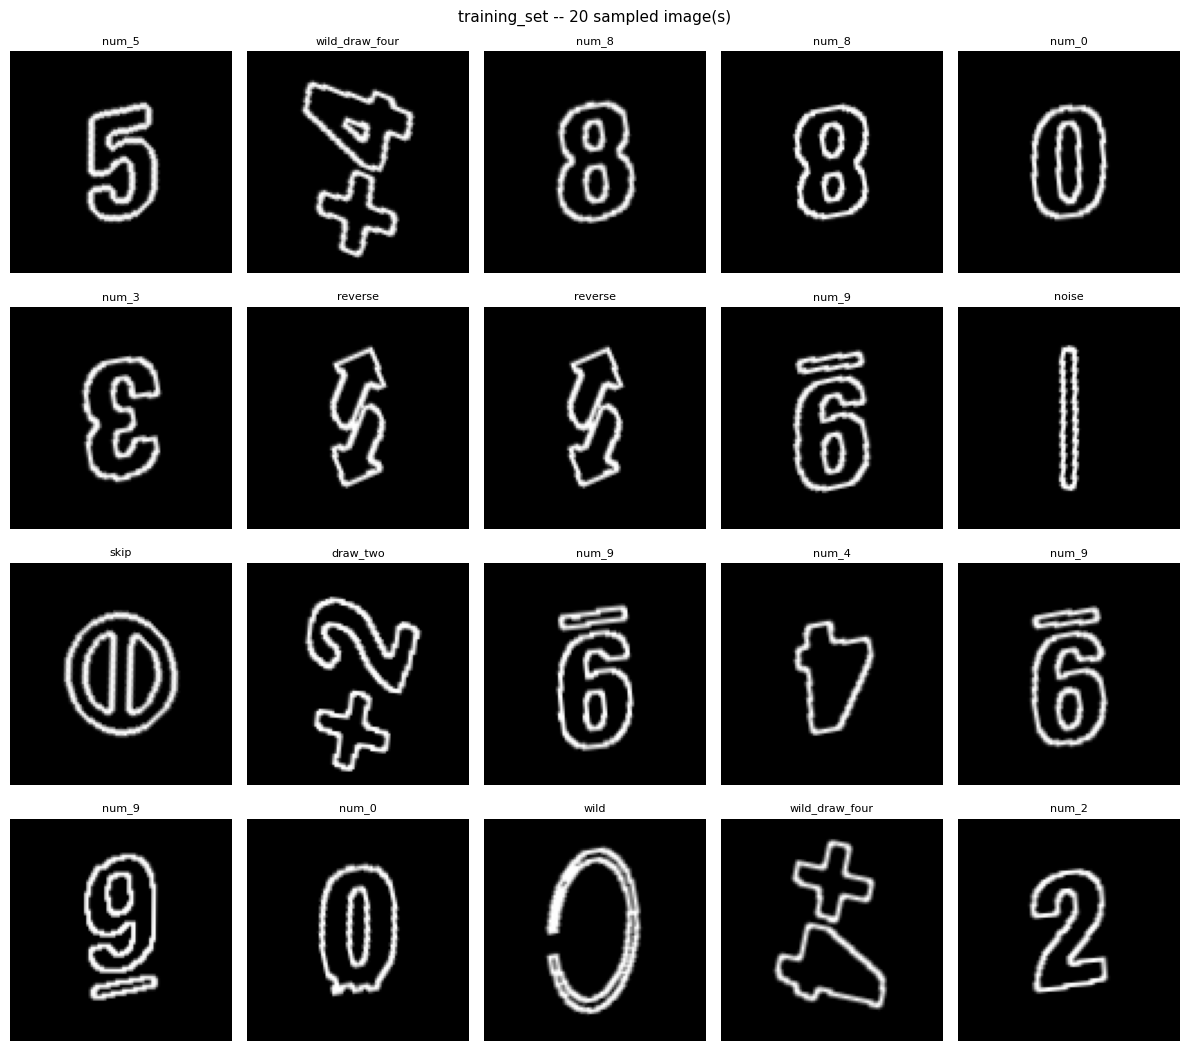

In [3]:
# ==========================================================================
# TRAINING-SET PREPARATION
# Run this AFTER the per-folder label CSVs have been filled in by hand.
# Builds <output>/training_set/<label>/ from a labelled CSV; the 'discard'
# class is ignored. Pass class_distribution={label: count} for a custom mix;
# omit it (or None) for an even split across all classes.
# ==========================================================================
LABEL_CSV     = "./symbol_dataset_v1/labels_v1.csv"
CANDIDATE_DIR = "./symbol_dataset_v1/symbol_full_dataset_original/"  # searched recursively
TRAINING_OUT  = "./symbol_dataset_v1/train_set/"                                # training_set created here

train_set_dir = prepare_training_dataset(
    LABEL_CSV, CANDIDATE_DIR, TRAINING_OUT,
    class_distribution=None,   # None -> even split; or e.g. {"num_7": 80, "noise": 80}
    show_data=SHOW_PLOTS,
    seed=SEED,
)


data_augmentation
--------------------------------------------------
  source set     : ./symbol_dataset_v1/train_set/training_set  (untouched)
  augmented set  : symbol_dataset_v1\augmented_train_set\training_set
  target count   : 200 image(s) per class
  enabled steps  : ['rotate_180deg', 'rotate_90deg', 'rotate_10deg', 'scale', 'translate', 'jitter_noise']
  class          before  ->  after   (+generated)
    draw_two         14   ->   200   (+186)
    noise            14   ->   200   (+186)
    num_0            14   ->   200   (+186)
    num_1            14   ->   200   (+186)
    num_2            14   ->   200   (+186)
    num_3            14   ->   200   (+186)
    num_4            14   ->   200   (+186)
    num_5            14   ->   200   (+186)
    num_6            14   ->   200   (+186)
    num_7            14   ->   200   (+186)
    num_8            14   ->   200   (+186)
    num_9            14   ->   200   (+186)
    reverse          14   ->   200   (+186)
    skip       

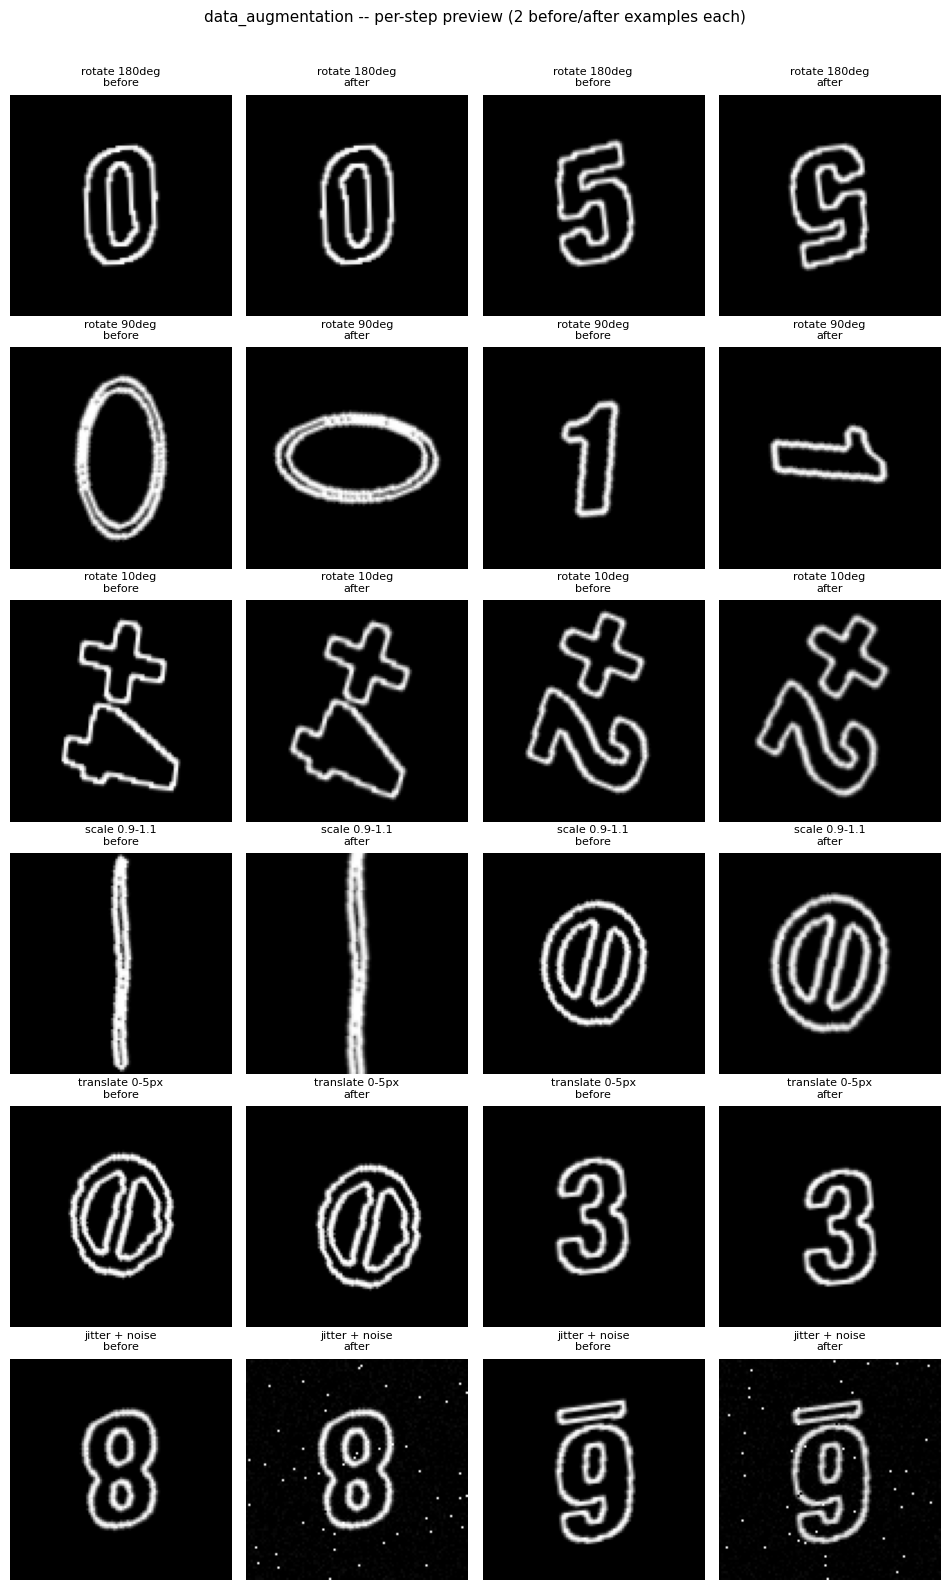

'symbol_dataset_v1\\augmented_train_set\\training_set'

In [4]:
# ==========================================================================
# DATA AUGMENTATION
# Run this AFTER prepare_training_dataset has built the training_set.
# Tops every class up to AUG_MIN_PER_CLASS images (originals + augmented)
# by chaining the enabled transform steps. All six steps are enabled,
# including the 90-deg and 180-deg rotations.
# ==========================================================================
AUG_MIN_PER_CLASS = 200   # minimum number of images per class after augmentation

data_augmentation(
    train_set_dir,              # training_set built by prepare_training_dataset
    count=AUG_MIN_PER_CLASS,
    rotate_180deg=True,
    rotate_90deg=True,
    rotate_10deg=True,
    scale=True,
    translate=True,
    jitter_noise=True,
    show_result=SHOW_PLOTS,
    seed=SEED,
)
